# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 

from encoder_observer import (
    image_encoder_monkey_patch, 
    ImageEncoderViTObserver
) 
from utils import get_activation_boxplot, to_numpy,  inference_image
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt

from segment_anything.modeling.image_encoder import (
    Attention,
    Block,
    ImageEncoderViT,
)

from segment_anything.modeling.image_encoder import (
    window_partition,
    window_unpartition,
)
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWar

In [2]:
model_type = "vit_l"
num_calib_samples = 1
checkpoint_path = "./pretrained_checkpoint/sam_hq_vit_l.pth"

# Initialize model and predictor
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to("cuda")
predictor = SamPredictor(sam)

image_encoder_monkey_patch(
    predictor.model,
    processor=None,
    n_bits=8,
    weight_quant="per_channel",
    act_quant="per_token",
)

/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = tor

<All keys matched successfully>


(1000, 894, 3)


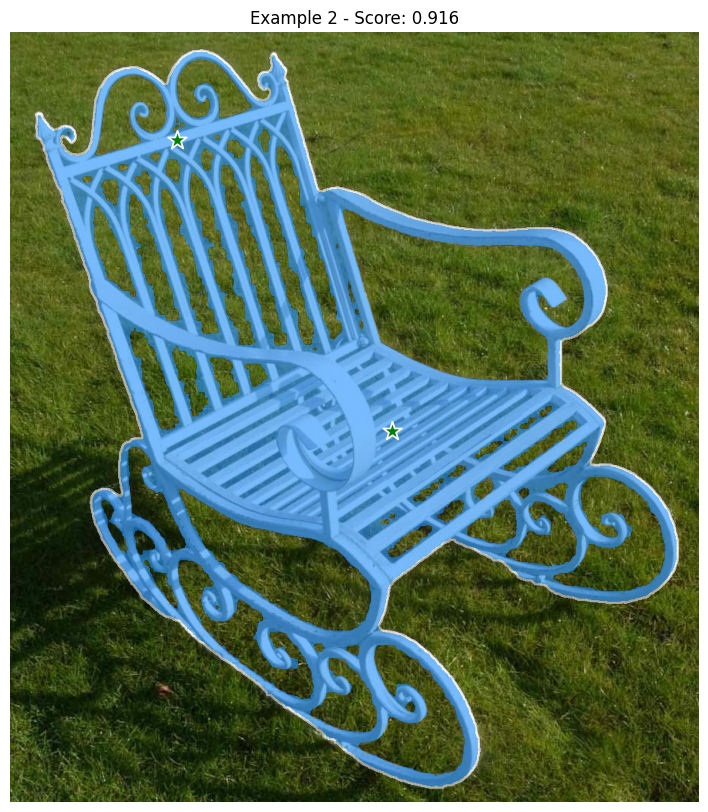

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]),
 array([0.9160991], dtype=float32),
 array([[[ -8.99022  , -10.917561 ,  -9.474711 , ...,  -7.761476 ,
           -9.115015 ,  -8.52656  ],
         [ -9.460696 , -11.748161 ,  -9.226687 , ...,  -8.746831 ,
           -9.837939 ,  -9.680134 ],
         [ -9.543961 , -11.6646   , -10.241977 , ...,  -8.247243 ,
          -10.65298  , -10.842402 ],
         ...,
         [ -7.9057035, -11.351597 , -10.494916 , ...,  -5.052666 ,
           -6.681713 ,  -6.1080675],
         [ -9.783154 , -11.477319 , -11.14697  , ...,  -6.14458  ,
           -7.5765467,  -7.119673 ],
         [-10.222233 , -11.415159 , -10.625482 , ...,  -5.750884 

In [3]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
inference_image(predictor, image_dir='./input_imgs/', example_idx=2, show_image=True)

In [4]:
ImageEncoderViTObserver.attention_score.keys()

dict_keys(['block_0_x', 'block_0_attn', 'block_0_O', 'block_0_O_qha', 'block_0_O_qfull', 'block_1_x', 'block_1_attn', 'block_1_O', 'block_1_O_qha', 'block_1_O_qfull', 'block_2_x', 'block_2_attn', 'block_2_O', 'block_2_O_qha', 'block_2_O_qfull', 'block_3_x', 'block_3_attn', 'block_3_O', 'block_3_O_qha', 'block_3_O_qfull', 'block_4_x', 'block_4_attn', 'block_4_O', 'block_4_O_qha', 'block_4_O_qfull', 'block_5_x', 'block_5_attn', 'block_5_O', 'block_5_O_qha', 'block_5_O_qfull', 'block_6_x', 'block_6_attn', 'block_6_O', 'block_6_O_qha', 'block_6_O_qfull', 'block_7_x', 'block_7_attn', 'block_7_O', 'block_7_O_qha', 'block_7_O_qfull', 'block_8_x', 'block_8_attn', 'block_8_O', 'block_8_O_qha', 'block_8_O_qfull', 'block_9_x', 'block_9_attn', 'block_9_O', 'block_9_O_qha', 'block_9_O_qfull', 'block_10_x', 'block_10_attn', 'block_10_O', 'block_10_O_qha', 'block_10_O_qfull', 'block_11_x', 'block_11_attn', 'block_11_O', 'block_11_O_qha', 'block_11_O_qfull', 'block_12_x', 'block_12_attn', 'block_12_O'

In [5]:

def get_attention_map(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn'][0]
    return attn

# def get_attention_map_mean(layer_idx:int):
#     attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn_mean'][0]
#     return attn

def get_feature(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_x'][0]
    return x
def get_O(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O'][0]
    return x
def get_O_qha(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O_qha'][0]
    return x
def get_O_qfull(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O_qfull'][0]
    return x
# def get_q(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q'][0]
#     return x
# def get_k(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_k'][0]
#     return x
# def get_v(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v'][0]
#     return x

# def get_q_mean(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q_mean'][0]
#     return x
# def get_v_mean(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v_mean'][0]
#     return x




In [ ]:
import numpy as np
layer_idx = 12  # Replace with your desired layer index
head_idx = 2  
norm_high_total = 0
norm_full_total = 0
for i in range(24):
    layer_idx=i
    O_origin = get_O(layer_idx)
    O_qha = get_O_qha(layer_idx)
    O_qfull = get_O_qfull(layer_idx)
    # print("O_origin:", O_origin.shape)
    # print("O_qha:", O_qha.shape)
    # print("O_qfull:", O_qfull.shape)

    diff_h = O_origin - O_qha
    diff_f = O_origin - O_qfull
    norm_high = np.linalg.norm(diff_h)
    norm_full = np.linalg.norm(diff_f)
    norm_high_total += norm_high
    norm_full_total += norm_full
    ratio = norm_high / norm_full 
    print("layer:", i, "ratio: ",ratio)
norm_high_total /=24
norm_full_total /=24
print("norm_high_total:", norm_high_total)
print("norm_full_total:", norm_full_total)
ratio = norm_high_total / norm_full_total
print(ratio)
layer: 0 ratio:  0.6100849
layer: 1 ratio:  0.7967727
layer: 2 ratio:  0.730721
layer: 3 ratio:  0.58155215
layer: 4 ratio:  0.64177364
layer: 5 ratio:  0.8755786
layer: 6 ratio:  0.84780943
layer: 7 ratio:  0.7921859
layer: 8 ratio:  0.8425216
layer: 9 ratio:  0.7583481
layer: 10 ratio:  0.8194197
layer: 11 ratio:  0.9345526
layer: 12 ratio:  0.7678498
layer: 13 ratio:  0.74675536
layer: 14 ratio:  0.75630695
layer: 15 ratio:  0.73839897
layer: 16 ratio:  0.77468604
layer: 17 ratio:  0.9447185
layer: 18 ratio:  0.81241095
layer: 19 ratio:  0.81280077
layer: 20 ratio:  0.8255297
layer: 21 ratio:  0.8278536
layer: 22 ratio:  0.8296719
layer: 23 ratio:  0.97192717
norm_high_total: 120.04772265752156
norm_full_total: 142.54122122128805
0.8421965353527702

layer: 0 ratio:  0.6670074
layer: 1 ratio:  0.8367103
layer: 2 ratio:  0.7678462
layer: 3 ratio:  0.6127835
layer: 4 ratio:  0.6870784
layer: 5 ratio:  0.90687156
layer: 6 ratio:  0.8653109
layer: 7 ratio:  0.83157504
layer: 8 ratio:  0.8689767
layer: 9 ratio:  0.790138
layer: 10 ratio:  0.84045774
layer: 11 ratio:  0.9524356
layer: 12 ratio:  0.8004996
layer: 13 ratio:  0.7943273
layer: 14 ratio:  0.7982094
layer: 15 ratio:  0.78472525
layer: 16 ratio:  0.8238981
layer: 17 ratio:  0.9582095
layer: 18 ratio:  0.85567516
layer: 19 ratio:  0.8563116
layer: 20 ratio:  0.8672538
layer: 21 ratio:  0.8617671
layer: 22 ratio:  0.85984653
layer: 23 ratio:  0.9797105
norm_high_total: 124.26445007324219
norm_full_total: 142.54122122128805
0.871779047552342

layer: 0 ratio:  0.73624516
layer: 1 ratio:  0.8676258
layer: 2 ratio:  0.80221236
layer: 3 ratio:  0.6503716
layer: 4 ratio:  0.7309956
layer: 5 ratio:  0.93400776
layer: 6 ratio:  0.87912244
layer: 7 ratio:  0.86138624
layer: 8 ratio:  0.8842686
layer: 9 ratio:  0.81134695
layer: 10 ratio:  0.85446197
layer: 11 ratio:  0.96346056
layer: 12 ratio:  0.82327986
layer: 13 ratio:  0.82646817
layer: 14 ratio:  0.8310284
layer: 15 ratio:  0.81975335
layer: 16 ratio:  0.8567817
layer: 17 ratio:  0.9672039
layer: 18 ratio:  0.88540536
layer: 19 ratio:  0.88410944
layer: 20 ratio:  0.8919691
layer: 21 ratio:  0.88548595
layer: 22 ratio:  0.87883526
layer: 23 ratio:  0.98451847
norm_high_total: 127.32406719525655
norm_full_total: 142.54122122128805
0.8932438357434328

How to know whether thesenumber are really significant


Low
layer: 0 ratio:  0.55115634
layer: 1 ratio:  0.31951872
layer: 2 ratio:  0.42658502
layer: 3 ratio:  0.66927034
layer: 4 ratio:  0.5719055
layer: 5 ratio:  0.15245633
layer: 6 ratio:  0.4035624
layer: 7 ratio:  0.3461372
layer: 8 ratio:  0.32182083
layer: 9 ratio:  0.44263998
layer: 10 ratio:  0.41473123
layer: 11 ratio:  0.11677208
layer: 12 ratio:  0.43005833
layer: 13 ratio:  0.40145823
layer: 14 ratio:  0.39184266
layer: 15 ratio:  0.4024921
layer: 16 ratio:  0.30697104
layer: 17 ratio:  0.08911218
layer: 18 ratio:  0.2608979
layer: 19 ratio:  0.2738603
layer: 20 ratio:  0.24675958
layer: 21 ratio:  0.2770088
layer: 22 ratio:  0.31385764
layer: 23 ratio:  0.09126773
norm_low_total: 37.62139368057251
norm_full_total: 143.10764845212302
0.2628887700097932



layer: 0 ratio:  0.55115634
layer: 1 ratio:  0.31951872
layer: 2 ratio:  0.42658502
layer: 3 ratio:  0.66927034
layer: 4 ratio:  0.5719055
layer: 5 ratio:  0.15245633
layer: 6 ratio:  0.4035624
layer: 7 ratio:  0.3461372
layer: 8 ratio:  0.32182083
layer: 9 ratio:  0.44263998
layer: 10 ratio:  0.41473123
layer: 11 ratio:  0.11677208
layer: 12 ratio:  0.43005833
layer: 13 ratio:  0.40145823
layer: 14 ratio:  0.39184266
layer: 15 ratio:  0.4024921
layer: 16 ratio:  0.30697104
layer: 17 ratio:  0.08911218
layer: 18 ratio:  0.2608979
layer: 19 ratio:  0.2738603
layer: 20 ratio:  0.24675958
layer: 21 ratio:  0.2770088
layer: 22 ratio:  0.31385764
layer: 23 ratio:  0.09126773
norm_high_total: 37.62139368057251
norm_full_total: 143.10764845212302
0.2628887700097932


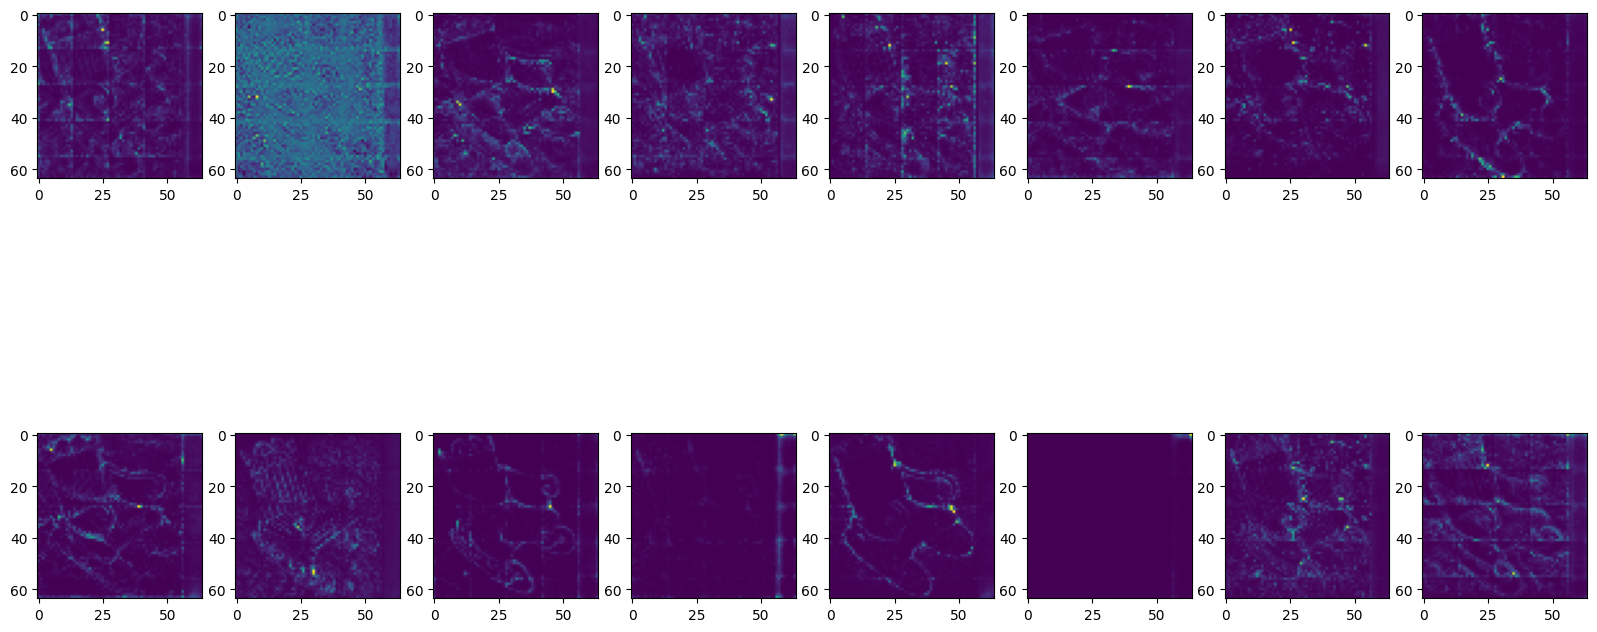

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot  as plt

def cal_energy(X:torch.Tensor, margin=0.9):
    """
    Calculate the energy of the input tensor.
    """
    X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
    score_map = F.elu(X @ X.transpose(-1, -2) - margin)
    scores = score_map.mean(-1)
    return scores

def recal_attn(q, k, v):
    attn = (q * 1/8) @ k.transpose(-2, -1)
    attn = attn.softmax(dim=-1)
    return attn

head_idx = 0
layer_idx = 17 
# q = get_q(layer_idx)[head_idx]
# k = get_k(layer_idx)[head_idx]
# v = get_k(layer_idx)[head_idx]

ori_attn = get_attention_map(layer_idx)
# attn_mean = get_attention_map(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(2,8,figsize=(20,10))
for i in range(8):
    axes[0][i].imshow(ori_attn[2*i].mean(0).reshape(64,64))
    axes[1][i].imshow(ori_attn[2*i+1].mean(0).reshape(64,64))
# print(energy_scores.shape)

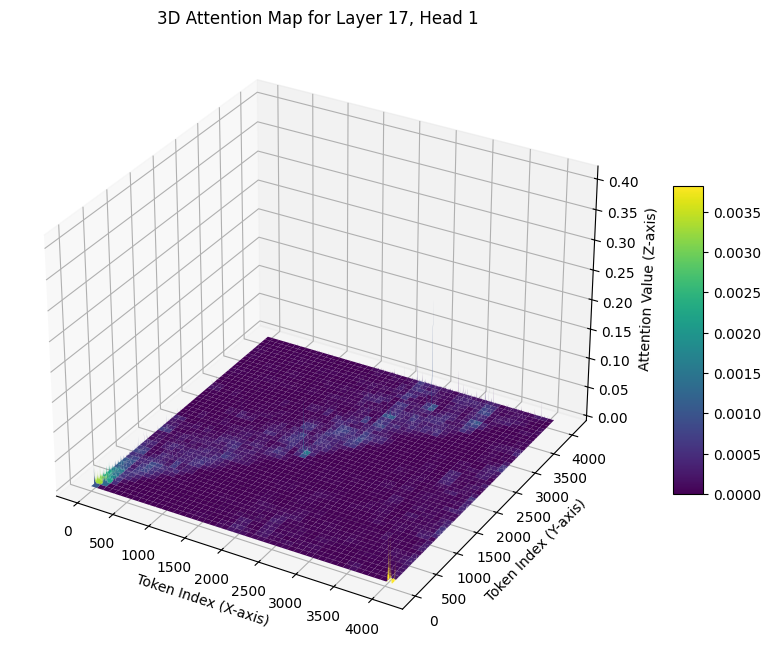

In [13]:
layer_idx = 17  # Replace with your desired layer index
head_idx = 1    # Replace with your desired head index

# Get the attention map for the selected layer
ori_attn = get_attention_map(layer_idx)

# Extract the attention map for the selected head
selected_head_attn = ori_attn[head_idx]  # Shape: (N, N), where N is the number of tokens

# Plot the distribution of all rows
# fig, axes = plt.subplots(8, 8, figsize=(20, 20))  # Adjust grid size as needed
# num_rows = selected_head_attn.shape[0]

# for i in range(min(num_rows, 64)):  # Plot up to 64 rows
#     row_data = selected_head_attn[i]  # Extract the row
#     ax = axes[i // 8, i % 8]  # Determine subplot position
#     ax.hist(row_data, bins=30, alpha=0.7, color='blue',log =True)  # Plot histogram
#     ax.set_title(f"Row {i}")
#     ax.set_xlim(0, 1)  # Adjust x-axis limits if needed
#     ax.set_ylim(0, 50)  # Adjust y-axis limits if needed

# plt.tight_layout()
# plt.show()


# plot 3d attention score
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
num_tokens = selected_head_attn.shape[0]
num_tokensy =num_tokens
x = np.arange(num_tokens)
y = np.arange(num_tokens)
X, Y = np.meshgrid(x, y)

# Convert the attention map to a numpy array for plotting
Z = selected_head_attn[:,:]
# sum = Z.sum(axis=1, keepdims=True)
# print(sum)
# print(len(sum))
# Plot the 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Add labels and a color bar
ax.set_title(f"3D Attention Map for Layer {layer_idx}, Head {head_idx}")
ax.set_xlabel("Token Index (X-axis)")
ax.set_ylabel("Token Index (Y-axis)")
ax.set_zlabel("Attention Value (Z-axis)")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.show()


# ori_attn = get_attention_map(layer_idx)
# ori_attn = get_attention_map(layer_idx)

# # Extract the attention map for the selected head
# selected_head_attn = ori_attn[head_idx]  # Shape: (N, N), where N is the number of tokens

# # Plot the 2D attention map
# plt.figure(figsize=(10, 8))
# plt.imshow(selected_head_attn, cmap='viridis', aspect='auto')

# # Add labels and a color bar
# plt.title(f"2D Attention Map for Layer {layer_idx}, Head {head_idx}")
# plt.xlabel("Token Index (X-axis)")
# plt.ylabel("Token Index (Y-axis)")
# plt.colorbar(label="Attention Value")

# plt.show()

### This if for mean of the map

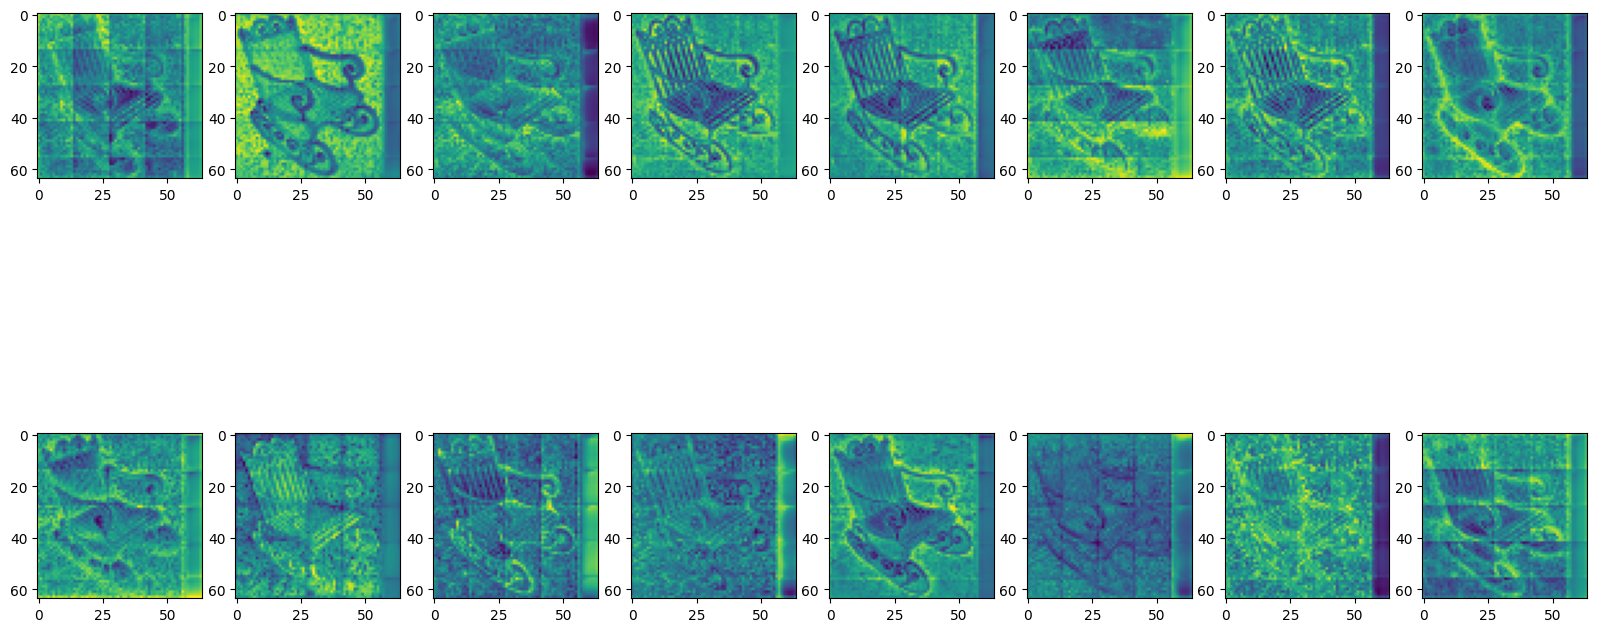

In [ ]:
attn_mean = get_attention_map_mean(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(2,8,figsize=(20,10))
for i in range(8):
    axes[0][i].imshow(attn_mean[2*i].mean(0).reshape(64,64))
    axes[1][i].imshow(attn_mean[2*i+1].mean(0).reshape(64,64))

torch.Size([4096])


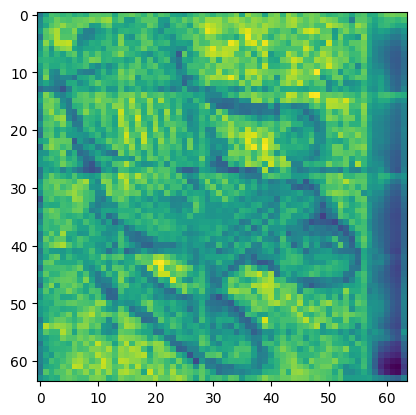

In [25]:
energy_scores =cal_energy(torch.from_numpy(q))
plt.imshow(energy_scores.reshape(64,64))
print(energy_scores.shape)

In [16]:
ori_attn.shape
re_cal_attn.shape

NameError: name 're_cal_attn' is not defined

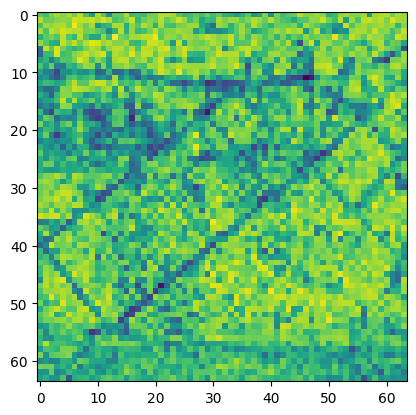

In [ ]:
plt.imshow(energy_scores.reshape(64,64))